# ANALISIS DE SENTIMIENTO DE TWEETS CON WORD2VEC Y REGRESIÓN LOGISTICA
# DATASET : https://www.kaggle.com/datasets/saurabhshahane/twitter-sentiment-dataset

# 1 - instalamos librerias

In [1]:
import pandas as pd
import numpy as np
import re
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# 2 - cargamos dataset

In [2]:
df = pd.read_csv('/content/Twitter_Data.csv')
df

,clean_text,category
0,when modi promised “minimum government maximum...,-1.0
1,talk all the nonsense and continue all the dra...,0.0
2,what did just say vote for modi welcome bjp t...,1.0
3,asking his supporters prefix chowkidar their n...,1.0
4,answer who among these the most powerful world...,1.0
...,...,...
162975,why these 456 crores paid neerav modi not reco...,-1.0
162976,dear rss terrorist payal gawar what about modi...,-1.0
162977,did you cover her interaction forum where she ...,0.0
162978,there big project came into india modi dream p...,0.0


# EDA

In [3]:
df.dtypes

,0
clean_text,object
category,float64


In [4]:
df.isnull().sum()

,0
clean_text,4
category,7


In [5]:
df.dropna(inplace=True)

# LIMPIEZA DE TEXTO SIMPLE

In [6]:
def clean_text(s: str) -> str:
    s = str(s).lower()
    s = re.sub(r"http\S+|www\S+", " url ", s)
    s = re.sub(r"@\w+", " user ", s)
    s = re.sub(r"#", " ", s)
    s = re.sub(r"\d+", " num ", s)
    s = re.sub(r"[^a-z\s]", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

In [7]:
df = df[['clean_text', 'category']].copy()
df = df.dropna()

# category puede venir como float, por eso lo convertimos
df['category'] = df['category'].astype(int)

df["text"] = df["clean_text"].astype(str).apply(clean_text)
df

,clean_text,category,text
0,when modi promised “minimum government maximum...,-1,when modi promised minimum government maximum ...
1,talk all the nonsense and continue all the dra...,0,talk all the nonsense and continue all the dra...
2,what did just say vote for modi welcome bjp t...,1,what did just say vote for modi welcome bjp to...
3,asking his supporters prefix chowkidar their n...,1,asking his supporters prefix chowkidar their n...
4,answer who among these the most powerful world...,1,answer who among these the most powerful world...
...,...,...,...
162975,why these 456 crores paid neerav modi not reco...,-1,why these num crores paid neerav modi not reco...
162976,dear rss terrorist payal gawar what about modi...,-1,dear rss terrorist payal gawar what about modi...
162977,did you cover her interaction forum where she ...,0,did you cover her interaction forum where she ...
162978,there big project came into india modi dream p...,0,there big project came into india modi dream p...


# hacemos label encoding

In [8]:
# Etiquetas originales del dataset:
# -1 = negative
#  0 = neutral
#  1 = positive

le = LabelEncoder()
y = le.fit_transform(df["category"])   # -1,0,1 -> 0,1,2
X_text = df["text"].tolist()

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text, y, test_size=0.2, random_state=42, stratify=y
)

print("Clases originales:", list(le.classes_))
print("Train:", len(X_train_text), "Test:", len(X_test_text))
print("Distribución train:", pd.Series(y_train).value_counts(normalize=True).sort_index().round(3).to_dict())
print("Distribución test:", pd.Series(y_test).value_counts(normalize=True).sort_index().round(3).to_dict())

Clases originales: [np.int64(-1), np.int64(0), np.int64(1)]
Train: 130375 Test: 32594
Distribución train: {0: 0.218, 1: 0.339, 2: 0.443}
Distribución test: {0: 0.218, 1: 0.339, 2: 0.443}


# ENTRENAMIENTO CON WORD2VEC

In [9]:
!pip -q install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 68.2 MB/s eta 0:00:00


In [10]:
from gensim.models import Word2Vec

In [11]:
train_tokens = [t.split() for t in X_train_text]
test_tokens  = [t.split() for t in X_test_text]

w2v = Word2Vec(
    sentences=train_tokens,
    vector_size=100,
    window=4,
    min_count=1,
    workers=4,
    sg=1,        # 1 = skip-gram
    epochs=10
)

print("Word2Vec listo. Vocab size:", len(w2v.wv))

Word2Vec listo. Vocab size: 87807


# Vectorizar cada tweet

In [12]:
def sent_vec(tokens, model):
    vecs = [model.wv[w] for w in tokens if w in model.wv]
    if len(vecs) == 0:
        return np.zeros(model.vector_size)
    return np.mean(vecs, axis=0)

X_train_vec = np.vstack([sent_vec(t, w2v) for t in train_tokens])
X_test_vec  = np.vstack([sent_vec(t, w2v) for t in test_tokens])

X_train_vec.shape, X_test_vec.shape

((130375, 100), (32594, 100))

# ENTRENAMIENTO

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

clf_w2v = LogisticRegression(max_iter=3000, multi_class='auto')
clf_w2v.fit(X_train_vec, y_train)

y_pred = clf_w2v.predict(X_test_vec)

print(classification_report(y_test, y_pred, target_names=[str(c) for c in le.classes_]))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


              precision    recall  f1-score   support

          -1       0.50      0.26      0.34      7102
           0       0.63      0.62      0.63     11042
           1       0.61      0.76      0.67     14450

    accuracy                           0.60     32594
   macro avg       0.58      0.55      0.55     32594
weighted avg       0.59      0.60      0.59     32594

Confusion matrix:
 [[ 1865  1576  3661]
 [  839  6884  3319]
 [ 1046  2489 10915]]


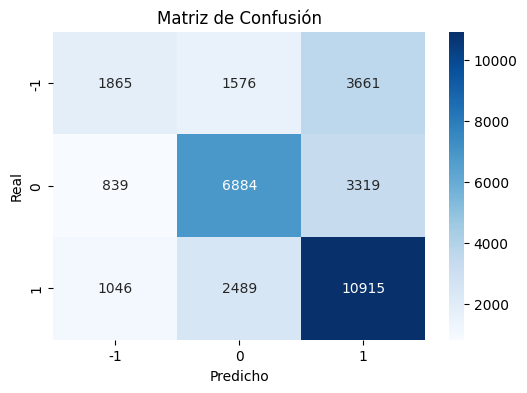

In [14]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(
    conf_matrix,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=[str(c) for c in le.classes_],
    yticklabels=[str(c) for c in le.classes_]
)
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.title('Matriz de Confusión')
plt.show()

# PROBAMOS PREDICCIONES

In [15]:
def predict_sentiment_w2v(msg: str):
    msg = clean_text(msg)
    tokens = msg.split()
    v = sent_vec(tokens, w2v).reshape(1, -1)

    pred_idx = clf_w2v.predict(v)[0]
    pred_label = le.inverse_transform([pred_idx])[0]

    probs = clf_w2v.predict_proba(v)[0]
    prob_dict = {
        str(label): float(prob)
        for label, prob in zip(le.classes_, probs)
    }

    return int(pred_label), prob_dict

print(predict_sentiment_w2v("I love this phone, it is amazing"))
print(predict_sentiment_w2v("This service is terrible and very bad"))
print(predict_sentiment_w2v("The product is okay, nothing special"))

(1, {'-1': 0.04308456711501884, '0': 0.07646379682869357, '1': 0.8804516360562876})
(1, {'-1': 0.14462632811606552, '0': 0.00027620118589301957, '1': 0.8550974706980414})
(1, {'-1': 0.23175913965762454, '0': 0.14088920034838276, '1': 0.6273516599939927})
